In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # Use Agg backend for non-interactive plotting environments
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Ensuring the plt module uses a non-interactive backend

%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
# Load the dataset

df=pd.read_csv("Exam_Score_Prediction.csv")
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [3]:
df = df.drop('student_id', axis=1)

In [4]:
df

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [5]:
missing_values = df.isnull().sum()

print(missing_values)


age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   internet_access   20000 non-null  object 
 6   sleep_hours       20000 non-null  float64
 7   sleep_quality     20000 non-null  object 
 8   study_method      20000 non-null  object 
 9   facility_rating   20000 non-null  object 
 10  exam_difficulty   20000 non-null  object 
 11  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 1.8+ MB


Numeric columns: ['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']


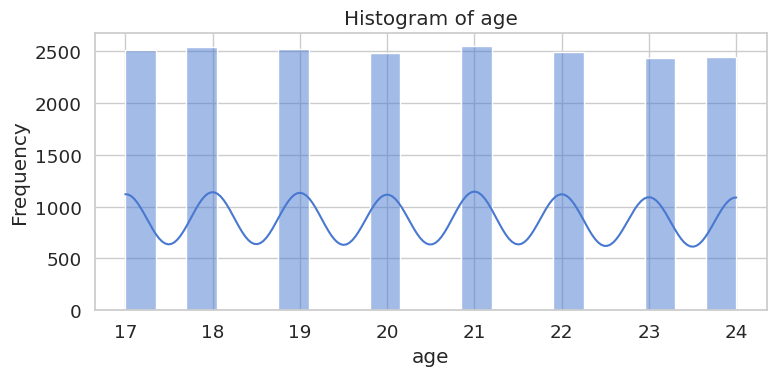

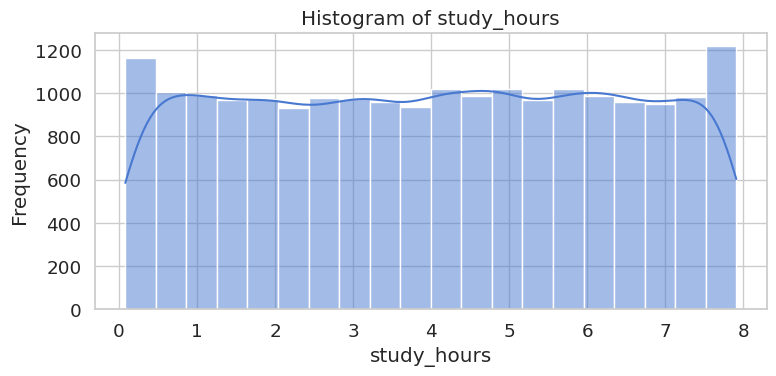

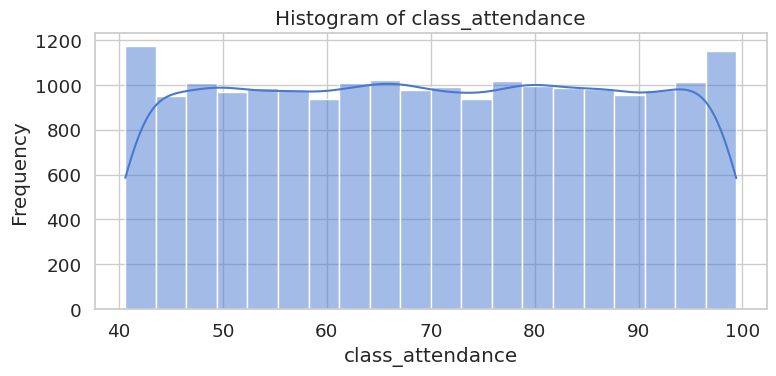

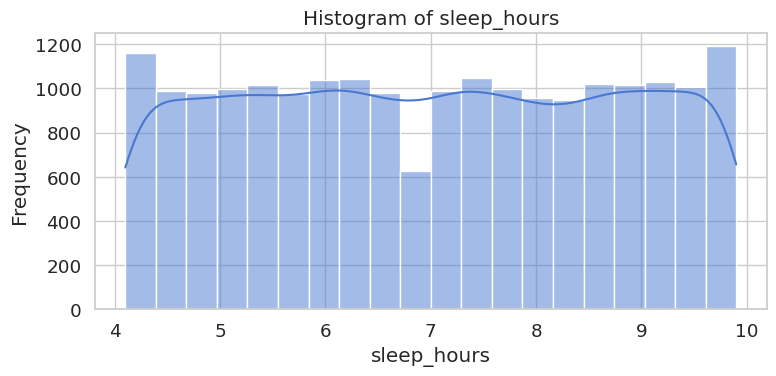

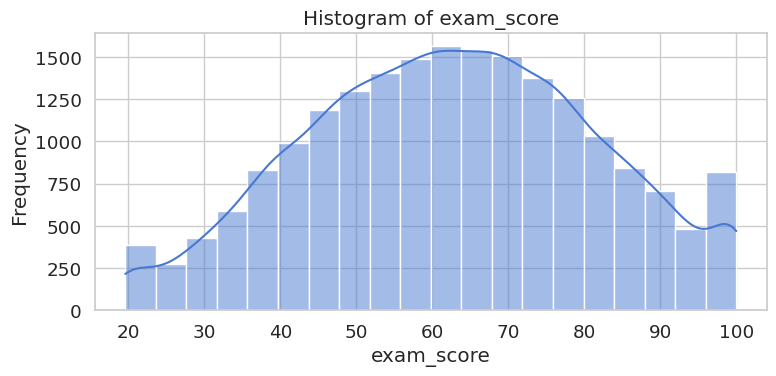

In [7]:
# Histogram for numerical features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', numeric_cols)

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


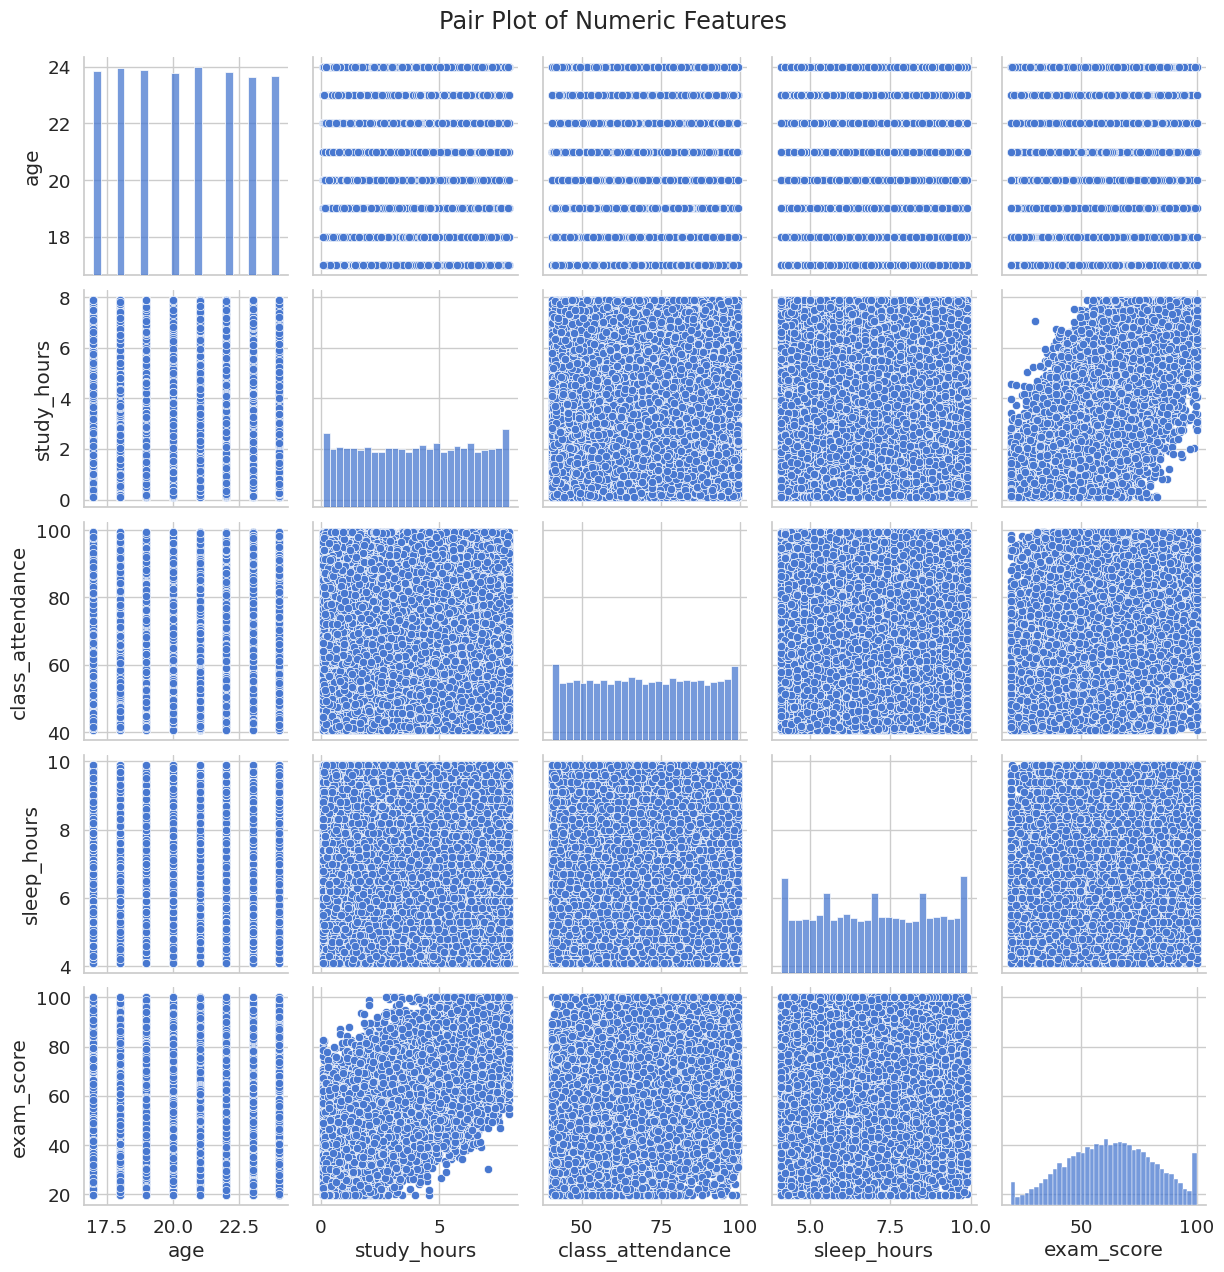

In [8]:
# Pair Plot
sns.pairplot(df[numeric_cols])
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

In [9]:

for col in df.columns:
    if df[col].dtype != 'int64' and df[col].dtype != 'float64':
        print(f'{col} : {df[col].unique()}')


gender : ['male' 'other' 'female']
course : ['diploma' 'bca' 'b.sc' 'b.tech' 'bba' 'ba' 'b.com']
internet_access : ['yes' 'no']
sleep_quality : ['poor' 'average' 'good']
study_method : ['coaching' 'online videos' 'mixed' 'self-study' 'group study']
facility_rating : ['low' 'medium' 'high']
exam_difficulty : ['hard' 'moderate' 'easy']


In [10]:
df['gender']=df['gender'].map({'male':1, 'other':2, 'female':3})

In [11]:
df['course']=df['course'].map({'diploma':1, 'bca':2, 'b.tech':3, 'b.sc':4, 'bba':5, 'ba':6, 'b.com':7})

In [12]:
df['internet_access']=df['internet_access'].map({'yes':1, 'no':2})

In [13]:
df['sleep_quality']=df['sleep_quality'].map({'poor':1, 'average':2, 'good':3})

In [14]:
df['study_method']=df['study_method'].map({'coaching':1, 'online videos':2, 'mixed':3, 'self-study':4, 'group study':5})

In [15]:
df['facility_rating']=df['facility_rating'].map({'low':1, 'medium':2, 'high':3})

In [16]:
df['exam_difficulty']=df['exam_difficulty'].map({'hard':1, 'moderate':2, 'easy':3})

In [17]:
df

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,1,1,2.78,92.9,1,7.4,1,1,1,1,58.9
1,23,2,2,3.37,64.8,1,4.6,2,2,2,2,54.8
2,22,1,4,7.88,76.8,1,8.5,1,1,3,2,90.3
3,20,2,1,0.67,48.4,1,5.8,2,2,1,2,29.7
4,20,3,1,0.89,71.6,1,9.8,1,1,1,2,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,2,5,6.50,71.3,1,5.0,3,4,1,3,86.5
19996,18,1,7,3.71,41.6,2,5.9,2,1,2,2,60.9
19997,19,2,1,7.88,68.2,1,4.6,1,5,1,3,64.5
19998,19,1,5,4.60,76.3,2,6.1,3,4,2,2,79.0


In [18]:
df.corr()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
age,1.000000,0.002496,-0.010047,0.002955,0.008449,0.005839,-0.000385,0.002849,-0.003542,0.009201,-0.010811,0.006522
gender,0.002496,1.000000,-0.002123,-0.004620,0.006990,0.002483,0.011913,0.019535,-0.002833,-0.001072,-0.002136,0.003987
course,-0.010047,-0.002123,1.000000,-0.005452,0.004443,-0.000216,0.003274,0.003508,0.000646,-0.004139,0.001311,-0.002115
study_hours,0.002955,-0.004620,-0.005452,1.000000,-0.001645,0.012706,-0.004533,-0.003493,-0.009197,-0.006144,-0.008463,0.717788
class_attendance,0.008449,0.006990,0.004443,-0.001645,1.000000,-0.006729,0.007187,-0.007896,0.001079,0.003939,0.005029,0.308850
internet_access,0.005839,0.002483,-0.000216,0.012706,-0.006729,1.000000,0.010066,-0.005958,0.007993,0.002306,-0.000655,0.007826
sleep_hours,-0.000385,0.011913,0.003274,-0.004533,0.007187,0.010066,1.000000,0.013813,0.001492,-0.006989,0.005838,0.133222
sleep_quality,0.002849,0.019535,0.003508,-0.003493,-0.007896,-0.005958,0.013813,1.000000,0.006125,-0.002119,-0.003806,0.198888
study_method,-0.003542,-0.002833,0.000646,-0.009197,0.001079,0.007993,0.001492,0.006125,1.000000,0.004112,-0.010032,-0.124725
facility_rating,0.009201,-0.001072,-0.004139,-0.006144,0.003939,0.002306,-0.006989,-0.002119,0.004112,1.000000,0.002525,0.162923


In [19]:
df

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,1,1,2.78,92.9,1,7.4,1,1,1,1,58.9
1,23,2,2,3.37,64.8,1,4.6,2,2,2,2,54.8
2,22,1,4,7.88,76.8,1,8.5,1,1,3,2,90.3
3,20,2,1,0.67,48.4,1,5.8,2,2,1,2,29.7
4,20,3,1,0.89,71.6,1,9.8,1,1,1,2,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,2,5,6.50,71.3,1,5.0,3,4,1,3,86.5
19996,18,1,7,3.71,41.6,2,5.9,2,1,2,2,60.9
19997,19,2,1,7.88,68.2,1,4.6,1,5,1,3,64.5
19998,19,1,5,4.60,76.3,2,6.1,3,4,2,2,79.0


In [20]:
print(df.columns)


Index(['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'], dtype='object')


In [21]:
df['age']=(df['age']-df['age'].min())/(df['age'].max()-df['age'].min())

In [22]:
df['study_hours']=(df['study_hours']-df['study_hours'].min())/(df['study_hours'].max()-df['study_hours'].min())

In [23]:
df['class_attendance']=(df['class_attendance']-df['class_attendance'].min())/(df['class_attendance'].max()-df['class_attendance'].min())

In [24]:
df['exam_score']=(df['exam_score']-df['exam_score'].min())/(df['exam_score'].max()-df['exam_score'].min())

In [25]:
df['gender']=(df['gender']-df['gender'].min())/(df['gender'].max()-df['gender'].min())

In [26]:
df['course']=(df['course']-df['course'].min())/(df['course'].max()-df['course'].min())

In [27]:
df['internet_access']=(df['internet_access']-df['internet_access'].min())/(df['internet_access'].max()-df['internet_access'].min())

In [28]:
df['sleep_hours']=(df['sleep_hours']-df['sleep_hours'].min())/(df['sleep_hours'].max()-df['sleep_hours'].min())

In [29]:
df['sleep_quality']=(df['sleep_quality']-df['sleep_quality'].min())/(df['sleep_quality'].max()-df['sleep_quality'].min())

In [30]:
df['study_method']=(df['study_method']-df['study_method'].min())/(df['study_method'].max()-df['study_method'].min())

In [31]:
df['facility_rating']=(df['facility_rating']-df['facility_rating'].min())/(df['facility_rating'].max()-df['facility_rating'].min())

In [32]:
df['exam_difficulty']=(df['exam_difficulty']-df['exam_difficulty'].min())/(df['exam_difficulty'].max()-df['exam_difficulty'].min())

In [33]:
df

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0.000000,0.0,0.000000,0.344828,0.889456,0.0,0.568966,0.0,0.00,0.0,0.0,0.488812
1,0.857143,0.5,0.166667,0.420179,0.411565,0.0,0.086207,0.5,0.25,0.5,0.5,0.437818
2,0.714286,0.0,0.500000,0.996169,0.615646,0.0,0.758621,0.0,0.00,1.0,0.5,0.879355
3,0.428571,0.5,0.000000,0.075351,0.132653,0.0,0.293103,0.5,0.25,0.0,0.5,0.125633
4,0.428571,1.0,0.000000,0.103448,0.527211,0.0,0.982759,0.0,0.00,0.0,0.5,0.299760
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.142857,0.5,0.666667,0.819923,0.522109,0.0,0.155172,1.0,0.75,0.0,1.0,0.832092
19996,0.142857,0.0,1.000000,0.463602,0.017007,1.0,0.310345,0.5,0.00,0.5,0.5,0.513688
19997,0.285714,0.5,0.000000,0.996169,0.469388,0.0,0.086207,0.0,1.00,0.0,1.0,0.558463
19998,0.285714,0.0,0.666667,0.577267,0.607143,1.0,0.344828,1.0,0.75,0.5,0.5,0.738809


In [34]:
# Split the dataset into training and test sets
X = df.drop('exam_score', axis=1)
y = df['exam_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predict on the test set
y_pred_lin = lin_reg.predict(X_test)

# Calculate performance metrics
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print('Linear Regression Results:')
print(f'Mean Squared Error: {mse_lin:.2f}')
print(f'R2 Score: {r2_lin:.2f}')

Linear Regression Results:
Mean Squared Error: 0.02
R2 Score: 0.71


In [36]:
# Decision Tree Regression Model
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)

# Predict on the test set
y_pred_dt = dt_reg.predict(X_test)

# Calculate performance metrics
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print('Decision Tree Regression Results:')
print(f'Mean Squared Error: {mse_dt:.2f}')
print(f'R2 Score: {r2_dt:.2f}')

Decision Tree Regression Results:
Mean Squared Error: 0.03
R2 Score: 0.38


In [37]:
# Random Forest Regression Model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_reg.predict(X_test)

# Calculate performance metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print('Random Forest Regression Results:')
print(f'Mean Squared Error: {mse_rf:.2f}')
print(f'R2 Score: {r2_rf:.2f}')

Random Forest Regression Results:
Mean Squared Error: 0.02
R2 Score: 0.70


               Model       MSE  R2 Score
0  Linear Regression  0.015866  0.713270
1      Decision Tree  0.034432  0.377735
2      Random Forest  0.016799  0.696399


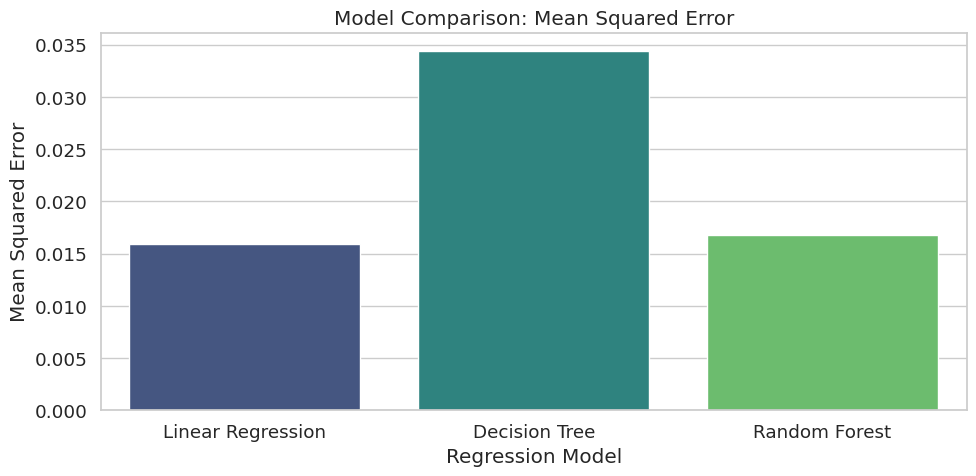

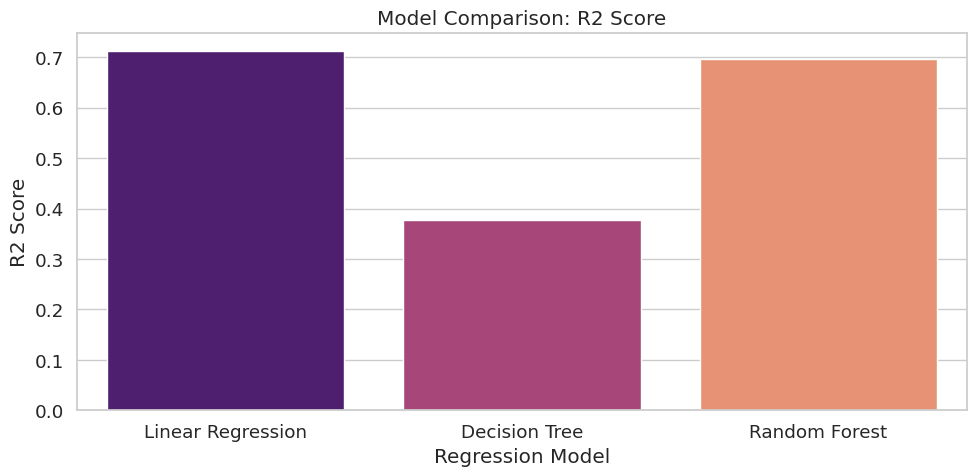

In [39]:
# Create a summary DataFrame for model comparison
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE': [mse_lin, mse_dt, mse_rf],
    'R2 Score': [r2_lin, r2_dt, r2_rf]
})

print(results)

# Bar Plot for MSE
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='MSE', data=results, palette='viridis')
plt.title('Model Comparison: Mean Squared Error')
plt.ylabel('Mean Squared Error')
plt.xlabel('Regression Model')
plt.tight_layout()
plt.show()

# Bar Plot for R2 Score
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='R2 Score', data=results, palette='magma')
plt.title('Model Comparison: R2 Score')
plt.ylabel('R2 Score')
plt.xlabel('Regression Model')
plt.tight_layout()
plt.show()

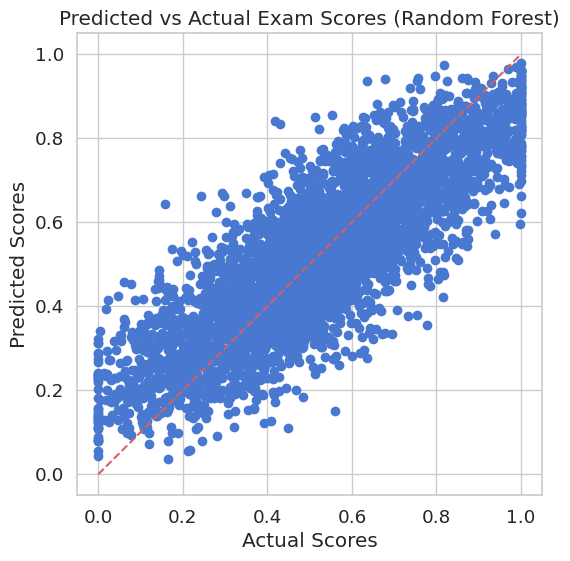

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Predicted vs Actual Exam Scores (Random Forest)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.savefig("pred_vs_actual.png")
plt.show()


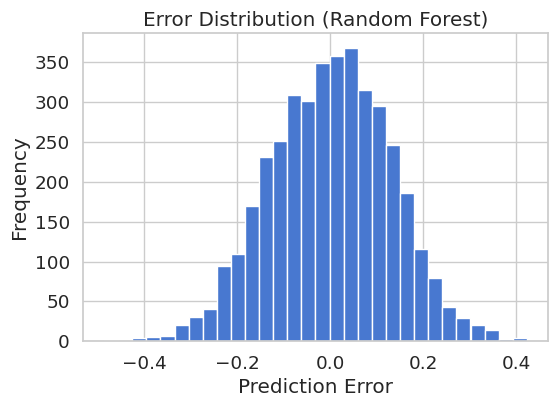

In [41]:
errors = y_test - y_pred_rf

plt.figure(figsize=(6,4))
plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Random Forest)")
plt.savefig("error_distribution.png")
plt.show()


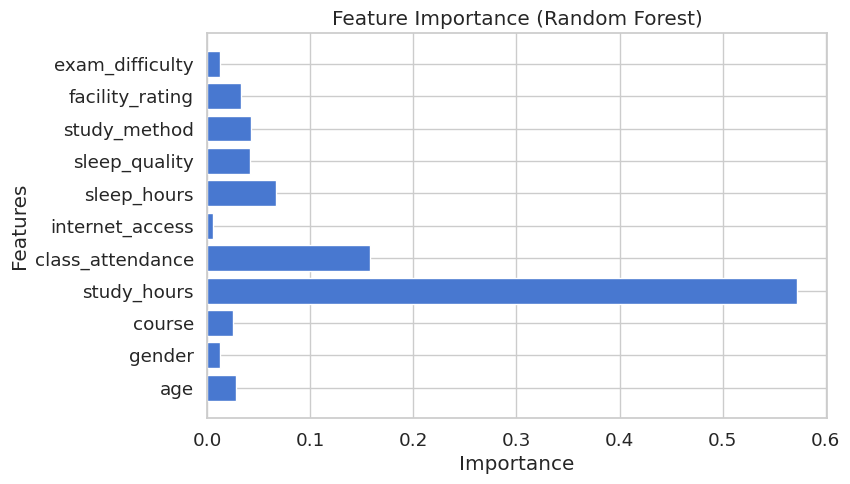

In [42]:
importances = rf_reg.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")
plt.savefig("feature_importance.png")
plt.show()


In [45]:
from google.colab import files
files.download("pred_vs_actual.png")
files.download("error_distribution.png")
files.download("feature_importance.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import pandas as pd

# ----------------------------
# Train-Test Split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# MODELS + HYPERPARAMETERS
# ----------------------------

models = [

    (
        'Linear Regression',
        LinearRegression(),
        {}   # Linear regression has no hyperparameters
    ),

    (
        'Decision Tree',
        DecisionTreeRegressor(random_state=42),
        {
            'model__max_depth': [None, 5, 10, 20],
            'model__criterion': ['squared_error', 'friedman_mse']
        }
    ),

    (
        'Random Forest',
        RandomForestRegressor(random_state=42),
        {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [None, 10, 20]
        }
    )
]

# ----------------------------
# TRAINING LOOP
# ----------------------------

results = []
best_model = None
best_r2 = -999

for name, model, param_grid in models:

    pipeline = Pipeline([
        ('model', model)
    ])

    # If model has hyperparameters, apply grid search
    if param_grid:
        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=3,
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_estimator = grid.best_estimator_
    else:
        # Linear Regression (no params)
        pipeline.fit(X_train, y_train)
        best_estimator = pipeline

    # Predictions
    y_pred = best_estimator.predict(X_test)

    # Evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results.append({
        "Model": name,
        "R2 Score": r2,
        "MSE": mse
    })

    print(f"\nModel: {name}")
    print("R2 Score:", round(r2, 4))
    print("MSE:", round(mse, 4))

    if r2 > best_r2:
        best_r2 = r2
        best_model = best_estimator

# ----------------------------
# SUMMARY
# ----------------------------

df = pd.DataFrame(results)
print("\nSummary:")
print(df)

print("\nBest Model:", best_model)
print("Best R2 Score:", best_r2)



Model: Linear Regression
R2 Score: 0.7133
MSE: 0.0159

Model: Decision Tree
R2 Score: 0.6052
MSE: 0.0218

Model: Random Forest
R2 Score: 0.7063
MSE: 0.0163

Summary:
               Model  R2 Score       MSE
0  Linear Regression  0.713270  0.015866
1      Decision Tree  0.605186  0.021847
2      Random Forest  0.706315  0.016251

Best Model: Pipeline(steps=[('model', LinearRegression())])
Best R2 Score: 0.7132703738638771


In [47]:
import pickle

# Save the best model to a pickle file
with open('best_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print("Best model saved as best_model.pkl")

Best model saved as best_model.pkl
